# Prepare

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import qutip as qt
from copy import deepcopy

import experiments as meas
from experiments.MM_dual_rail_base import MM_dual_rail_base
from fitting.fit_display_classes import GeneralFitting
from fitting.wigner import WignerAnalysis

from slab import AttrDict
from experiments import MultimodeStation, CharacterizationRunner, SweepRunner

from job_server import JobClient
from job_server.database import get_database
from job_server.config_versioning import ConfigVersionManager

# Initialize database and config manager
db = get_database()
config_dir = 'D:/python/multimode_expts/configs'
config_manager = ConfigVersionManager(config_dir)

# Initialize job client (handle submitting and waiting for jobs)
client = JobClient()

# Check server health
health = client.health_check()
print(f"Server status: {health['status']}")
print(f"Pending jobs: {health['pending_jobs']}")

user = "connie"
print("Welcome", user)



Failed to read module file 'd:\python\multimode_expts\.pixi\envs\default\Lib\pydoc_data\topics.py' for module 'pydoc_data.topics': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._boo

Failed to read module file 'd:\python\multimode_expts\.pixi\envs\default\Lib\shlex.py' for module 'shlex': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1324, in 

Importing all classes from  D:\python\multimode_expts\experiments\dual_rail
Importing all classes from  D:\python\multimode_expts\experiments\qsim
Importing all classes from  D:\python\multimode_expts\experiments\qubit_cavity
Importing all classes from  D:\python\multimode_expts\experiments\single_qubit
Skipped top-level files ['characterization_runner.py', 'dataset.py', 'MM_base.py', 'MM_dual_rail_base.py', 'MM_rb_base.py', 'mock_hardware.py', 'sequential_experiment.py', 'sequential_experiment_classes.py', 'station.py', 'sweep_runner.py']
Server status: healthy
Pending jobs: 0
Welcome connie


In [2]:
station = MultimodeStation(
    user=user,
    # experiment_name = "250119_qec",
    # experiment_name = "260227_qsim_purity_shots_test",
    experiment_name = "260403_qsim_calibrate_induced_kerrs",

    hardware_config = 'CFG-HW-20260404-00002',
    storage_man_file = 'CFG-M1-20260404-00028',
    floquet_file = 'CFG-FL-20260401-00021',

    # storage_man_file="CFG-M1-20260212-00022",
    # hardware_config="CFG-HW-20260211-00039",
)

USE_QUEUE = True

mm_base_calib = MM_dual_rail_base(station.hardware_cfg, station.soc)
# multiphoton_cfg_thisrun = AttrDict(deepcopy(mm_base_calib.multiphoton_cfg))

Failed to read module file 'D:\python\multimode_expts\experiments\qsim\t2_cavity_fluxexcursion.py' for module 'experiments.qsim.t2_cavity_fluxexcursion': UnicodeDecodeError
Traceback (most recent call last):
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ^^^^^^^^
  File "d:\python\multimode_expts\.pixi\envs\default\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in position 3793: character maps to <undefined>


[STATION] Using hardware_config version: CFG-HW-20260404-00002
[STATION] Using main multiphoton_config version: CFG-MP-20260121-00001
[STATION] Using man1_storage_swap version: CFG-M1-20260404-00028
[STATION] Using floquet_storage_swap version: CFG-FL-20260401-00021
Data, plots, logs will be stored in: D:\experiments\260403_qsim_calibrate_induced_kerrs
Hardware configs will be read from D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260404-00002.yml
dict_keys(['Pyro.NameServer', 'Qick101'])
QICK running on ZCU216, software version 0.2.291

Firmware configuration (built Tue Oct 15 12:06:51 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	7 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32-bit DDS, range=6389.760 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 32768 samples (5.128 us)
		fs=6389.760 MHz, fabric=399.360 MHz, 32

In [ ]:
coupler_current = 0.1e-3
# coupler_current = 0.5e-3

In [4]:
# station.hardware_cfg

In [5]:
station.ds_storage.df

,stor_name,freq (MHz),precision (MHz),pi (mus),h_pi (mus),gain (DAC units),last_update,bs_rate_coeffs_g,bs_rate_coeffs_e,freq_coeffs_g,freq_coeffs_e,gain_range_g,gain_range_e,joint_parity,dr_ac_stark_rate,dr_jp_phase
0,M1-S1,352.804975,NaN,2.352172,1.176086,3145.0,2026-03-03 08:28:49.177729,"[-1.2836395105770435e-12, 1.562696017091276e-0...","[-1.0271277777566499e-12, 1.2180616293411382e-...","[2.416727059292405e-18, -4.5676836555436063e-1...","[1.0768268119126192e-17, -2.064263277889986e-1...","[3139.0413060452993, 4847.324955685794]","[3101.448831598782, 4790.574447085415]","[352.945277297742, 3613, 3.633305169492332, 3....",NaN,NaN
1,M1-S2,524.652154,NaN,2.066902,1.153536,4119.0,2026-03-03 08:31:21.402037,"[-1.4281651019406063e-14, 2.806388588329146e-1...","[-1.3801639995141456e-14, 2.522836838797176e-1...","[3.168997973536308e-13, -5.187532491475121e-09...","[1.5879651422642703e-13, -2.550878518704292e-0...","[3768.329130027269, 4601.31156086655]","[3734.908431473402, 4579.9722200091655]","[524.7952187148321, 4126, 3.5772383566017147, ...",NaN,NaN
2,M1-S3,700.803883,NaN,1.696505,0.848253,4754.0,2026-03-03 08:33:50.371545,"[5.6421716124194476e-14, -9.54652575391602e-10...","[5.3668931659321213e-14, -9.081097405814645e-1...","[6.6423838139356915e-15, -1.0891788247748665e-...","[7.707647124928997e-15, -1.287562445371084e-10...","[3691.6725579408326, 4750.653565000185]","[3675.6253949570655, 4747.5907746229]","[700.9623452312223, 3898, 3.5574971282155756, ...",NaN,NaN
3,M1-S4,880.746852,NaN,2.347447,1.173723,5724.0,2026-03-03 08:36:23.348135,"[1.3074330883632018e-13, -3.895577532599537e-0...","[1.0440734314418517e-13, -3.1165658095145888e-...","[-1.7911015967743975e-13, 5.255316029156036e-0...","[1.183456340477642e-13, -3.4848271304432547e-0...","[7130.408130290509, 7845.801085058587]","[7106.808810897533, 7826.805864093215]",NaN,NaN,NaN
4,M1-S5,1057.057548,NaN,2.833119,1.416560,6123.0,2026-02-21 15:08:17.529746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M1-S6,1248.744497,NaN,2.236056,0.902242,10382.0,2026-03-03 08:38:55.422709,"[-1.3966876001204708e-16, 6.9291826510581826e-...","[-2.6880391715732103e-16, 1.302538630495037e-1...","[3.8362619693507795e-16, -1.8777580937514096e-...","[4.2919235562169526e-16, -2.0702799090883976e-...","[10695.78483095193, 14045.482358218112]","[10727.35496738184, 14406.811373274053]","[1248.8666467863163, 11486, 3.482493636565513,...",NaN,NaN
6,M1-S7,1426.863489,NaN,2.983754,1.491877,9840.0,2026-03-03 08:41:26.225786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M1-S8,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M1-S9,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M1-S10,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
from slab.datamanagement import SlabFile
import json
import os

"""Reopen saved data"""
def prev_data(expt_path, filename=None):
    temp_data_file = expt_path
    if filename is not None: temp_data_file = os.path.join(expt_path, filename)
    with SlabFile(temp_data_file) as a:
        attrs = dict()
        for key in list(a.attrs):
            attrs.update({key:json.loads(a.attrs[key])})
        keys = list(a)
        temp_data = dict()
        for key in keys:
            temp_data.update({key:np.array(a[key])})
        print(f'Extracted data and attrs {list(a.attrs)}')
    return temp_data, attrs

# Setting up the Wigner tomography

## Single shot

In [4]:
# Define defaults, smart config preprocessing and post-measurement updates
# =====================================
singleshot_defaults = AttrDict(dict(    
    reps=5000,
    relax_delay=500,
    check_f=False,
    active_reset=False,
    man_reset=False,
    storage_reset=False,
    qubit=0,
    pulse_manipulate=False,
    # cavity_freq=4984.373226159381,
    # cavity_gain=400,
    # cavity_length=2,
    prepulse=False,
    pre_sweep_pulse=None,
    gate_based=True,
    qubits=[0],
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def singleshot_postproc(station, expt):
    expt.analyze(plot=False, station=station, subdir=station.autocalib_path)
    fids = expt.data['fids']
    confusion_matrix = expt.data['confusion_matrix']
    thresholds_new = expt.data['thresholds']
    angle = expt.data['angle']
    print(fids)

    hardware_cfg = station.hardware_cfg
    hardware_cfg.device.readout.phase = [hardware_cfg.device.readout.phase[0] + angle]
    hardware_cfg.device.readout.threshold = thresholds_new
    hardware_cfg.device.readout.threshold_list = [thresholds_new]
    hardware_cfg.device.readout.Ie = [np.median(expt.data['Ie_rot'])]
    hardware_cfg.device.readout.Ig = [np.median(expt.data['Ig_rot'])]
    if expt.cfg.expt.active_reset:
        hardware_cfg.device.readout.confusion_matrix_with_active_reset = confusion_matrix
    else:
        hardware_cfg.device.readout.confusion_matrix_without_reset = confusion_matrix
    print('Updated readout!')

Job submitted: JOB-20260404-00061 (queue position: 1)

[0.4s] Job JOB-20260404-00061: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260404-00061_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 499.11it/s]
[26.7s] Job JOB-20260404-00061: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.26it/s]
Unrotated:
Ig -248.59864864864863 +/- 96.16148919964054 	 Qg -430.51756756756754 +/- 69.33400676031641 	 Amp g 497.13847577332945
Ie 213.3054054054054 +/- 116.92180650081808 	 Qe -409.2905405405405 +/- 65.86198733076863 	 Amp e 461.5386685329109
Rotated:
Ig -268.52539153528244 +/- 95.59088489848013 	 Qg -419.22881559347627 +/- 70.11860824957746 	 Amp g 497.85408075367394

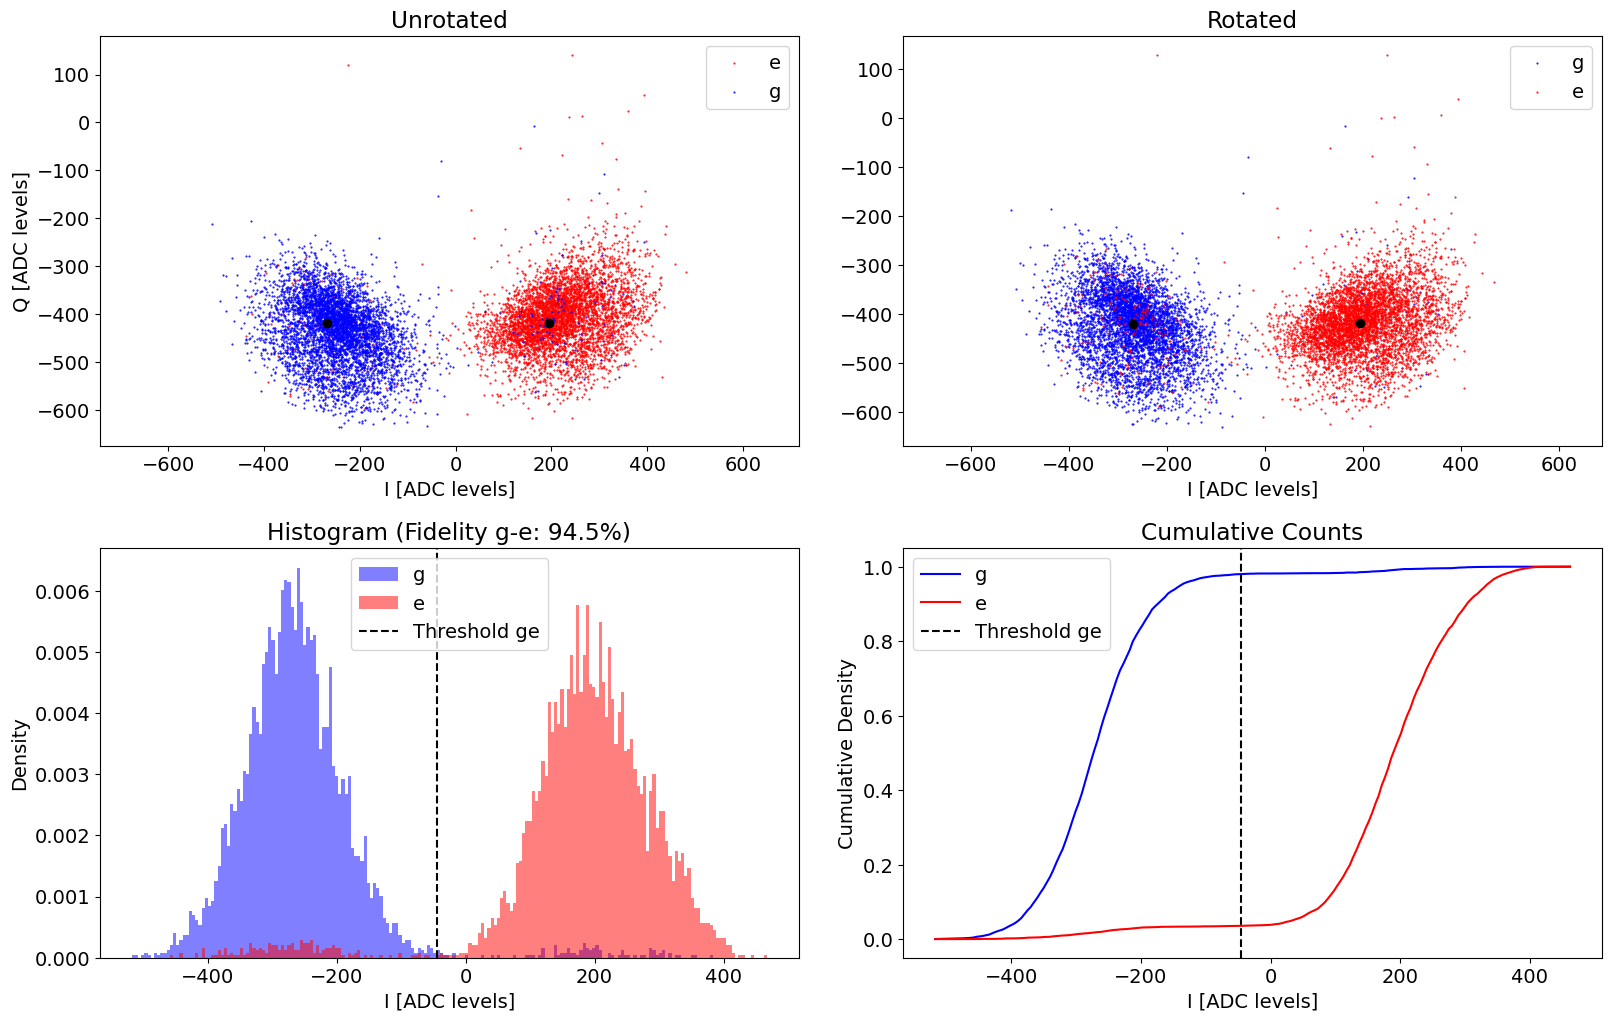

Plot saved to D:\experiments\260403_qsim_calibrate_induced_kerrs\plots\2026-04-04_21-49-41_histogram.png
Plot reference appended to D:\experiments\260403_qsim_calibrate_induced_kerrs\logs\2026-04-04.md
ge fidelity (%): 94.48000000000003
rotation angle (deg): -2.6312043644789576
threshold ge: -44.95787059771192


In [5]:
# Execute
# =================================
ss_runner = CharacterizationRunner(
    station = station,
    ExptClass = meas.HistogramExperiment,
    default_expt_cfg = singleshot_defaults,
    postprocessor = singleshot_postproc,
    job_client=client,
)

ss = ss_runner.execute(
    check_f=False,
    # active_reset=False, # on recalibration of readout, turn off active reset because it will be wrong for selecting when to apply the qubit pulse
    relax_delay=2000,

    # reps=10000,
    # active_reset=True,
    # relax_delay=200,
    priority=1,
)
ss.display(station)

In [7]:
station.snapshot_hardware_config(update_main=True)
# station.snapshot_hardware_config(update_main=False)

[CONFIG] Created new hardware_config version CFG-HW-20260225-00008
[CONFIG] Updated main hardware_config to CFG-HW-20260225-00008


'CFG-HW-20260225-00008'

In [ ]:
# station.snapshot_hardware_config(update_main=True)
# station.preview_config_update()

[CONFIG] Created new hardware_config version CFG-HW-20260203-00006
[CONFIG] Updated main hardware_config to CFG-HW-20260203-00006
Comparing configurations:
Parent config file: D:\python\multimode_expts\configs\versions\hardware_config\CFG-HW-20260202-00012.yml
Key 'device.readout.phase' differs:
  Old value (config1): [116.80805199604343]
  New value (config2): [86.79981357299127]
Key 'device.readout.threshold' differs:
  Old value (config1): [-43.579202343000475]
  New value (config2): [-43.220583393766674]
Key 'device.readout.threshold_list' differs:
  Old value (config1): [[-43.579202343000475]]
  New value (config2): [[-43.220583393766674]]
Key 'device.readout.confusion_matrix_without_reset' differs:
  Old value (config1): [0.9837999999999995, 0.016200000000000547, 0.03699999999999994, 0.9630000000000001]
  New value (config2): [0.9846, 0.01539999999999997, 0.03640728145629127, 0.9635927185437088]
Key 'device.readout.Ie' differs:
  Old value (config1): [15.409810234007871]
  New va

## Photon Number Resolved  Spectroscopy

This is used to check that the fock states are well prepared before we do the tomography

In [7]:
photon_number_spectro_defaults = AttrDict(dict(
    span=10,
    expts=200,
    reps=2000,
    rounds=1,
    length=1,
    gain=400,
    sigma=0.1,
    qubits=[0],
    qubit=0,
    prepulse=False,
    pre_sweep_pulse=[],
    gate_based=False,
    relax_delay=250,
))

def photon_number_spectro_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)

    expt_cfg.update(kwargs)
    center = kwargs.pop('center', station.hardware_cfg.device.qubit.f_ge[0])

    expt_cfg.start = kwargs.pop('start', center - expt_cfg.span / 2)
    expt_cfg.step = expt_cfg.span / expt_cfg.expts
    print("start", expt_cfg.start, "step", expt_cfg.step, expt_cfg.step*expt_cfg.expts, expt_cfg.length)
    
    return expt_cfg


photon_number_spectro_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.pulse_probe_spectroscopy.PulseProbeSpectroscopyExperiment,
    default_expt_cfg=photon_number_spectro_defaults,
    job_client=client,
    preprocessor=photon_number_spectro_preproc,
    use_queue=USE_QUEUE,
    # use_queue=False,
)

In [8]:
pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=1, photon_no=1)
pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
print(f"pre_sweep_pulse: {pre_sweep_pulse}")

pre_sweep_pulse: [[3563.16879314331, 3419.182966608824, 1998.6772114826442], [9288, 8243, 8000], [0, 0, 0.5717222607857422], [0, 0, 0], [2, 2, 0], ['gauss', 'gauss', 'flat_top'], [0.035, 0.035, 0.005]]


In [ ]:
span = 3
expt = 150
length = 15
gain = 200

photon_number_spectro = photon_number_spectro_runner.execute(
    pre_sweep_pulse=pre_sweep_pulse,
    prepulse=True,
    gate_based=False,
    length=length,
    sigma=1.,
    gain=gain,
    expts=expt,
    span=span,
    relax_delay=500,
    reps=500,
    # reps=20,
    # start=3562.5-2,
    coupler_current=coupler_current,
)

Found peak in amps at [MHz] 3562.3444999810845, HWHM 0.117234135511806
Found peak in I at [MHz] 3562.3435452214617, HWHM 0.11864730112274796
Found peak in Q at [MHz] 3562.344706159211, HWHM 0.11542846287307611


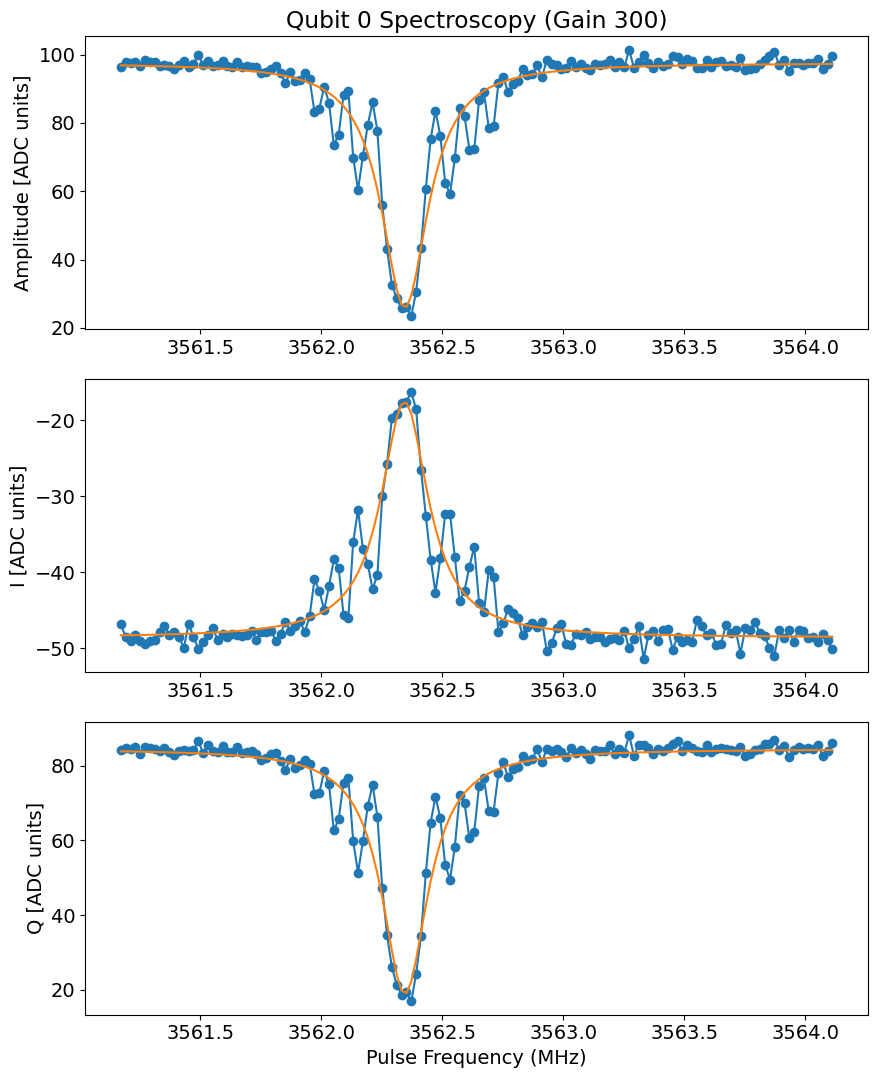

In [ ]:
photon_number_spectro.display()

## Parity Delay

In [6]:
parity_delay_defaults = AttrDict(dict(
    start=0.01,
    step=0.05,
    expts=50,
    reps=250,
    rounds=1,
    qubits=[0],
    parity_fast=False,
    normalize=False,
    active_reset=False,
    man_reset=True,
    gate_based=False,
    storage_reset=True,
    man_mode_no=1,
    relax_delay=2500, 
    param_to_calib='length', # length or ac_stark_shift 
    shift_sign=1, # 1 or -1 for ac stark shift direction
    ))


def parity_delay_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    if 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='ac_stark_shift':
        expt_cfg.prepulse = False
        expt_cfg.pre_sweep_pulse = []
    elif 'param_to_calib' in expt_cfg and expt_cfg.param_to_calib =='length':
        expt_cfg.prepulse = True
        pre_sweep_pulse = mm_base_calib.prep_man_photon(man_no=expt_cfg.man_mode_no, photon_no=1)
        pre_sweep_pulse = mm_base_calib.get_prepulse_creator(pre_sweep_pulse, station.hardware_cfg).pulse.tolist()
        expt_cfg.pre_sweep_pulse = pre_sweep_pulse
    return expt_cfg

def parity_delay_postproc(station, expt):
    from fitting.fit_display_classes import LengthRabiFitting
    # Analyze the data
    length_rabi_analysis = LengthRabiFitting(expt.data, config = expt.cfg)
    length_rabi_analysis.analyze(fitparams = [100, 0.1, 0, None, None, None])
    length_rabi_analysis.display(title_str='Length Rabi General F0g1')
    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    shift_sign = expt_cfg.shift_sign


    if expt_cfg.param_to_calib == 'length':
        delay = length_rabi_analysis.results['pi_length']
        print(f'Fitted revival time: {delay} us')
        old_delay = station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1] = delay

        # print("WARNING, NOT UPDATING ANY CONFIG PARAMS")
        print(f'Updated revival time for mode {man_mode_no}: {old_delay} -> {station.hardware_cfg.device.manipulate.revival_time[man_mode_no - 1]}')

    elif expt_cfg.param_to_calib == 'ac_stark_shift': 
        freq = length_rabi_analysis.data['fit_avgi'][1]
        print(f'Fitted ac Stark shift: {freq} MHz')
        old_freq = station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]

        # print("WARNING, NOT UPDATING ANY CONFIG PARAMS")
        station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1] += shift_sign * freq
        print(f'Updated ac Stark shift for mode {man_mode_no}: {old_freq} -> {station.hardware_cfg.device.manipulate.revival_stark_shift[man_mode_no - 1]}')

### Calibrate first the AC stark shift

Manipulate in 0, qubit should not rotate

this is calibrating the virtual Z to correct from rotating frame to bare frame

this is probably negligible if using parity_fast=False

Job submitted: JOB-20260304-00026 (queue position: 1)

[0.1s] Job JOB-20260304-00026: pending

[2.1s] Job JOB-20260304-00026: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260304-00026_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 94%|██████████████████████████████████████▌  | 94/100 [00:34<00:02,  2.55it/s]
[42.8s] Job JOB-20260304-00026: completed
100%|████████████████████████████████████████| 100/100 [00:36<00:00,  2.75it/s]
Saving D:\experiments\260227_qsim_purity_shots_test\data\JOB-20260304-00026_ParityDelayExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260227_qsim_purity_shots_test\expt_objs\JOB-20260304-00026_expt.pkl

Job completed! Data: D:\experiments\260227_qsim_purity_shots_test\data\JOB-20260304-00026_ParityDelayExperiment

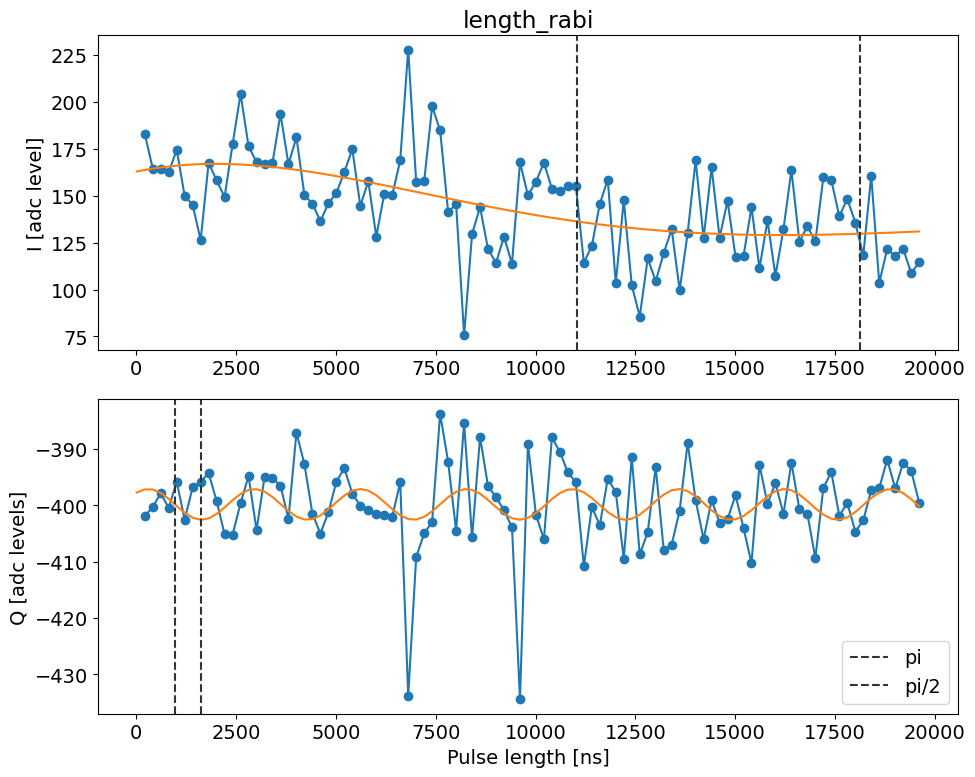

Fitted ac Stark shift: 0.03523047495057316 MHz
Updated ac Stark shift for mode 1: 0.005102040816355523 -> 0.04033251576692868


In [ ]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='ac_stark_shift', 
    step=0.2,
    expts=100,
    reps=100,
    shift_sign=+1,
    relax_delay=2500,
    priority=1,
)

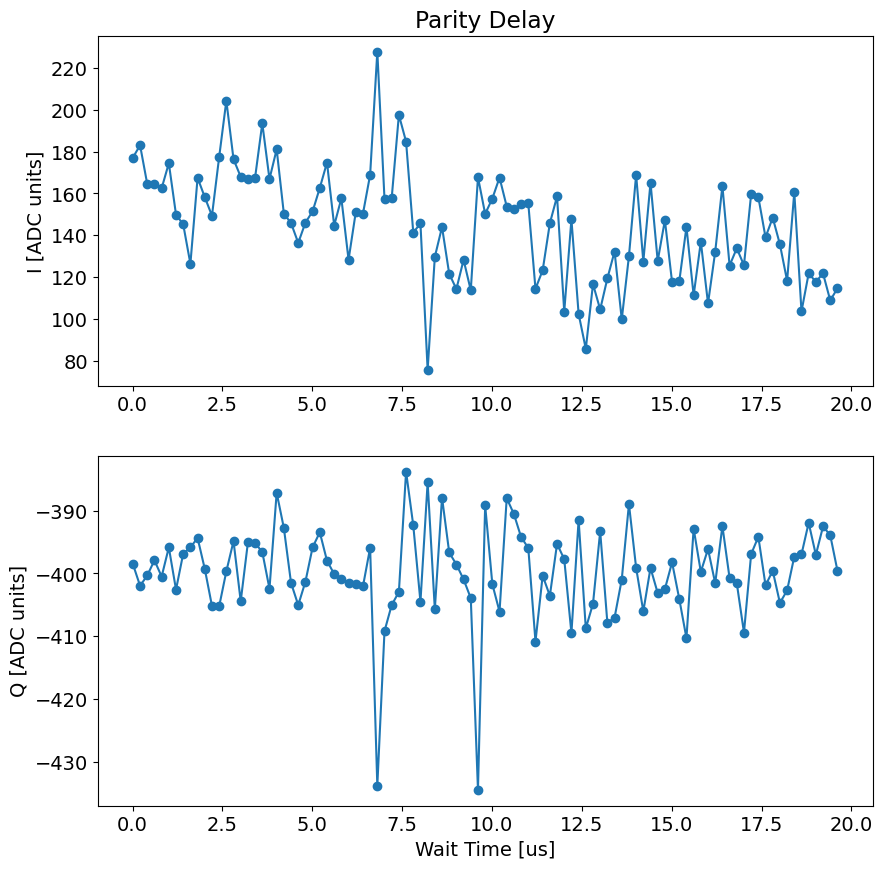

In [28]:
parity_delay_ac_stark.display(fit=False)

Confirming the correction is in the right direction

In [ ]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    preprocessor=parity_delay_preproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='ac_stark_shift', 
    step=0.2,
    expts=100,
    reps=100,
    priority=1,
)

In [ ]:
parity_delay_ac_stark.display(fit=False)

### IMPORTANT: now parity length after the AC stark shift is calibrated

Job submitted: JOB-20260404-00062 (queue position: 1)

[0.1s] Job JOB-20260404-00062: pending

[2.2s] Job JOB-20260404-00062: running
[WORKER] Loading ParityDelayExperiment from experiments.single_qubit.parity_delay
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260404-00062_ParityDelayExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|████████████████████████████████████████▌| 99/100 [01:02<00:00,  1.60it/s]
[70.7s] Job JOB-20260404-00062: completed
100%|████████████████████████████████████████| 100/100 [01:02<00:00,  1.59it/s]
D:\python\multimode_expts\fitting\fitting.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  pOpt, pCov = sp.optimize.curve_fit(expfunc, xdata, ydata, p0=fitparams, maxfev=200000)
Saving D:\experiments\260403_qsim_calibrate_induced_kerrs\data\JOB-20260404-00062_ParityDelayExperiment.h5
[WORKER] Savin

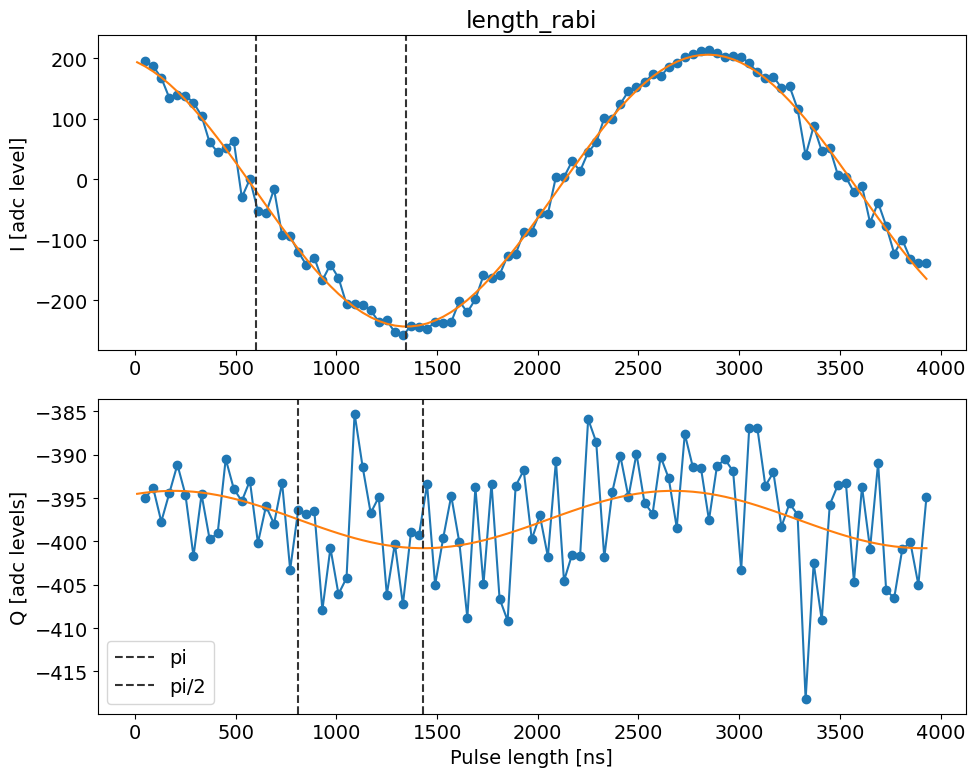

Fitted revival time: 1.3474738189892663 us
Updated revival time for mode 1: 1.35664013046921 -> 1.3474738189892663


In [7]:
parity_delay_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityDelayExperiment,
    default_expt_cfg=parity_delay_defaults,
    postprocessor=parity_delay_postproc,
    preprocessor=parity_delay_preproc,
    job_client=client,
)

parity_delay_ac_stark = parity_delay_runner.execute(
    param_to_calib='length', 
    step=0.04,
    expts=100,
    reps=200,
    priority=1,
)

## Manipulate Parity Spectroscopy

check the manipulate frequency (displacement freq)

In [12]:
parity_freq_defaults = AttrDict(dict(
    start=4960,
    stop=5020,
    step=0.60,
    reps=500,
    rounds=1,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=10000,
    span=20,
    man_mode_no=1,
    displace=(True, 0.1, 1000),
    const_pulse=(False, 1),
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500,
))

def parity_freq_postproc(station, expt):
    from fitting.fit_display_classes import Spectroscopy
    spec = Spectroscopy(expt.data, config=expt.cfg)
    spec.analyze()
    spec.display(title='Parity Frequency Experiment')

    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    fitted_freq = spec.data['fit_avgi'][2]
    old_freq = station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]
    station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1] = fitted_freq
    print(f'Updated manipulate f_ge for mode {man_mode_no} from {old_freq} to {fitted_freq}')


parity_freq_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.ParityFreqExperiment,
    default_expt_cfg=parity_freq_defaults,
    postprocessor=parity_freq_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)


Job submitted: JOB-20260403-00093 (queue position: 1)

[0.2s] Job JOB-20260403-00093: pending

[2.2s] Job JOB-20260403-00093: running
[WORKER] Loading ParityFreqExperiment from experiments.single_qubit.parity_freq
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260403-00093_ParityFreqExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 99%|████████████████████████████████████████▌| 99/100 [02:17<00:01,  1.45s/it]
[145.9s] Job JOB-20260403-00093: completed
100%|████████████████████████████████████████| 100/100 [02:19<00:00,  1.39s/it]
Saving D:\experiments\260403_qsim_calibrate_induced_kerrs\data\JOB-20260403-00093_ParityFreqExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260403_qsim_calibrate_induced_kerrs\expt_objs\JOB-20260403-00093_expt.pkl

Job completed! Data: D:\experiments\260403_qsim_calibrate_induced_kerrs\data\JOB-20260403-00093_Parity

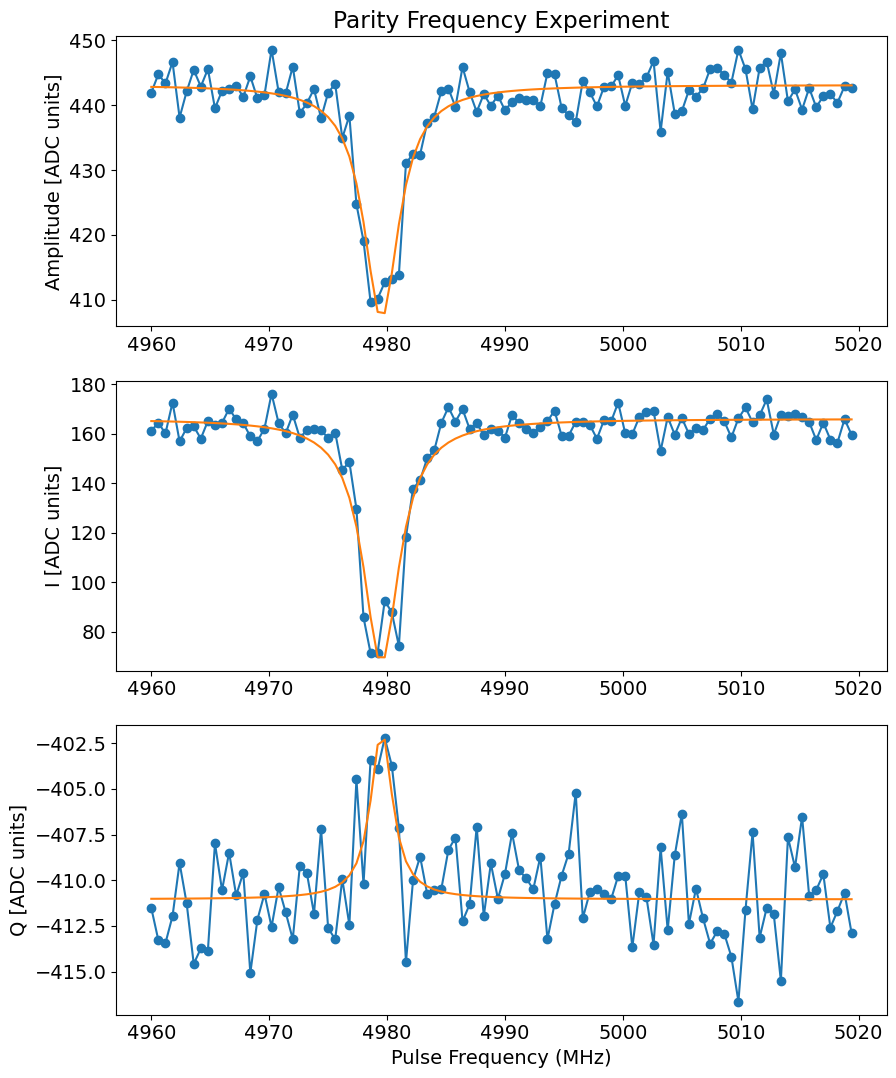

Updated manipulate f_ge for mode 1 from 4979.790775068981 to 4979.501937569862


In [14]:
parity_freq = parity_freq_runner.execute(
    priority=1,
)

## Manipulate Ramsey (to finetune frequency)
- This will use displace pulse instead do qubit pi/2 to calibrate; we want fine calibration of manipulate frequency not some fast way of extracting T2 time or finding stark shift on f0g1 transition
- Make sure displacements are small $(\alpha \approx 0.2)$
- Somehow i don't get full contrast, like the lowst i,q value dont correspond to g 




In [ ]:
cavity_ramsey_defaults = AttrDict(dict(
    start=0.01,           # start delay
    step=0.05,            # step size
    expts=200,            # number of experiments
    ramsey_freq=3.7,      # Ramsey frequency
    reps=100,              # repetitions
    rounds=1,             # rounds
    qubits=[0],           # qubits
    checkEF=False,        # check EF
    f0g1_cavity=0,        # f0g1 cavity
    init_gf=False,        # initialize gf
    active_reset=False,   # active reset
    man_reset=True,       # manipulate reset
    storage_reset=True,   # storage reset
    user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
    parity_meas=True,     # parity measurement
    man_mode_no=1,
    storage_ramsey=[False, 2, True], # storage Ramsey
    man_ramsey=None,      # manipulate Ramsey
    coupler_ramsey=False, # coupler Ramsey
    custom_coupler_pulse=None, # custom coupler pulse
    echoes=[False, 0],    # echoes
    prepulse=False,       # prepulse
    postpulse=False,      # postpulse
    gate_based=False,     # gate based
    pre_sweep_pulse=None, # pre sweep pulse
    post_sweep_pulse=None,# post sweep pulse
    prep_e_first = True,
    relax_delay=2500      # relax delay
))

def cavity_ramsey_preproc(station, default_expt_cfg, **kwargs):
    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)

    expt_cfg.man_idx = expt_cfg.man_mode_no - 1

    if expt_cfg.user_defined_pulse is None:
        expt_cfg.user_defined_pulse = [True, station.hardware_cfg.device.manipulate.f_ge[expt_cfg.man_mode_no-1], 10, station.hardware_cfg.device.manipulate.displace_sigma[expt_cfg.man_mode_no-1], 0, 4]

    if expt_cfg.man_ramsey is None:
        expt_cfg.man_ramsey = [False, expt_cfg.man_mode_no -1]
    if expt_cfg.custom_coupler_pulse is None:
        expt_cfg.custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
    if expt_cfg.pre_sweep_pulse is None:
        expt_cfg.pre_sweep_pulse = []
    if expt_cfg.post_sweep_pulse is None:
        expt_cfg.post_sweep_pulse = []
    # do we need to set the relax delay here?
    return expt_cfg

def cavity_ramsey_postproc(station, expt):

    from fitting.fit_display_classes import RamseyFitting
    ramsey_analysis = RamseyFitting(expt.data, config=expt.cfg)
    delta_f = min(ramsey_analysis.data['f_adjust_ramsey_avgi'])

    expt_cfg = expt.cfg.expt
    man_mode_no = expt_cfg.man_mode_no
    old_freq = station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]
    station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1] = old_freq + delta_f
    print(f'Updated manipulate f_ge for mode {man_mode_no} from {old_freq} to {station.hardware_cfg.device.manipulate.f_ge[man_mode_no - 1]}')

cavity_ramsey_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.t2_cavity.CavityRamseyExperiment,
    default_expt_cfg=cavity_ramsey_defaults,
    preprocessor=cavity_ramsey_preproc,
    postprocessor=cavity_ramsey_postproc,
    job_client=client,
)


# def do_cavity_ramsey_gain_sweep(
#     hardware_cfg,
#     expt_path,
#     config_path,
#     start=0.01,           # start delay
#     step=0.05,            # step size
#     expts=200,            # number of experiments
#     ramsey_freq=3.7,      # Ramsey frequency
#     gain_start = 1000,  # start gain
#     gain_step = 1000,      # step size for gain
#     gain_expts = 5,        # number of experiments for gain
#     reps=100,              # repetitions
#     rounds=1,             # rounds
#     qubits=[0],           # qubits
#     checkEF=False,        # check EF
#     f0g1_cavity=0,        # f0g1 cavity
#     init_gf=False,        # initialize gf
#     active_reset=False,   # active reset
#     man_reset=True,       # manipulate reset
#     storage_reset=True,   # storage reset
#     user_defined_pulse=None, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
#     parity_meas=True,     # parity measurement
#     man_mode_no=1,            
#     storage_ramsey=[False, 2, True], # storage Ramsey
#     man_ramsey=None,      # manipulate Ramsey
#     coupler_ramsey=False, # coupler Ramsey
#     custom_coupler_pulse=None, # custom coupler pulse
#     echoes=[False, 0],    # echoes
#     prepulse=False,       # prepulse
#     postpulse=False,      # postpulse
#     gate_based=False,     # gate based
#     pre_sweep_pulse=None, # pre sweep pulse
#     post_sweep_pulse=None,# post sweep pulse
#     relax_delay=2500,      # relax delay
#     do_g_and_e=False, # do e-f first
# ):
#     """
#     Run the Cavity Ramsey experiment using the specified configuration.
#     """
#     if user_defined_pulse is None:
#         user_defined_pulse = [True, station.hardware_cfg.device.manipulate.f_ge[man_mode_no-1], 1000, station.hardware_cfg.device.manipulate.displace_sigma[man_mode_no-1], 0,
#                                   4]
#     #[on/off, freq, gain, sigma (mus), phase, channel] 
#     if man_ramsey is None:
#         man_ramsey = [False, man_mode_no -1]
#     if custom_coupler_pulse is None:
#         custom_coupler_pulse = [[944.25], [1000], [0.316677658], [0], [1], ['flat_top'], [0.005]]
#     if pre_sweep_pulse is None:
#         pre_sweep_pulse = []
#     if post_sweep_pulse is None:
#         post_sweep_pulse = []

#     cavity_ramsey = expts_base_inst.meas.single_qubit.t2_cavity.CavityRamseyGainSweepExperiment(
#         soccfg=expts_base_inst.soc, path=expt_path, prefix='CavityRamseyGainSweepExperiment', config_file=config_path
#     )

#     cavity_ramsey.cfg = AttrDict(deepcopy(hardware_cfg))

#     cavity_ramsey.cfg.expt = dict(
#         start=start,                    # start delay
#         step=step,                      # step size
#         expts=expts,                    # number of experiments
#         ramsey_freq=ramsey_freq,        # Ramsey frequency
#         gain_start=gain_start,          # start gain
#         gain_step=gain_step,            # step size for gain
#         gain_expts=gain_expts,          # number of experiments for gain
#         reps=reps,                      # repetitions
#         rounds=rounds,                  # rounds
#         qubits=qubits,                  # qubits
#         checkEF=checkEF,                # check EF
#         f0g1_cavity=f0g1_cavity,        # f0g1 cavity
#         init_gf=init_gf,                # initialize gf
#         active_reset=active_reset,      # active reset
#         man_reset=man_reset,            # manipulate reset
#         storage_reset=storage_reset,    # storage reset
#         user_defined_pulse=user_defined_pulse, # [on/off, freq, gain, sigma (mus), 0, 4] # if off, use config freq
#         parity_meas=parity_meas,        # parity measurement
#         man_mode_no=man_mode_no,                # manipulate index
#         storage_ramsey=storage_ramsey,  # storage Ramsey
#         man_ramsey=man_ramsey,          # manipulate Ramsey
#         coupler_ramsey=coupler_ramsey,  # coupler Ramsey
#         custom_coupler_pulse=custom_coupler_pulse, # custom coupler pulse
#         echoes=echoes,                  # echoes
#         prepulse=prepulse,              # prepulse
#         postpulse=postpulse,            # postpulse
#         gate_based=gate_based,          # gate based
#         pre_sweep_pulse=pre_sweep_pulse,# pre sweep pulse
#         post_sweep_pulse=post_sweep_pulse, # post sweep pulse
#         do_g_and_e=do_g_and_e,  # do e-f first
#     )

#     cavity_ramsey.cfg.device.readout.relax_delay = [relax_delay]
#     cavity_ramsey.go(analyze=False, display=False, progress=True, save=True)
#     return cavity_ramsey



In [19]:
station.hardware_cfg.device.manipulate.f_ge[0]=4979.614305651117

cavity_ramsey = cavity_ramsey_runner.execute(
    ramsey_freq=0.5,
    step = 0.1,
    expts = 100,
    reps = 500,
    prep_e_first = False,
    user_defined_pulse=[True, station.hardware_cfg.device.manipulate.f_ge[0], 2000, 
                                station.hardware_cfg.device.manipulate.displace_sigma[0],
                                  0, 4],
)

Job submitted: JOB-20260403-00098 (queue position: 1)

[0.2s] Job JOB-20260403-00098: pending

[2.2s] Job JOB-20260403-00098: running
[WORKER] Loading CavityRamseyExperiment from experiments.single_qubit.t2_cavity
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260403-00098_CavityRamseyExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
100
 98%|██████████████████████████████████▍| 49140/50000 [02:03<00:02, 396.54it/s]
[152.5s] Job JOB-20260403-00098: completed
100%|███████████████████████████████████| 50000/50000 [02:05<00:00, 397.11it/s]
No echoes in the data
Saving D:\experiments\260403_qsim_calibrate_induced_kerrs\data\JOB-20260403-00098_CavityRamseyExperiment.h5
[WORKER] Saving expt object to: D:\experiments\260403_qsim_calibrate_induced_kerrs\expt_objs\JOB-20260403-00098_expt.pkl

Job completed! Data: D:\experiments\260403_qsim_calibrate_induced_kerrs\

Using user defined frequency: 4979.614305651117 MHz
Current pi pulse frequency: 4979.614305651117
Fit frequency from I [MHz]: 0.4937401274010773 +/- 0.0009219795192000473
Suggested new pi pulse frequency from fit I [MHz]:
 	4979.620565523716
 	4980.608045778518
T2 Ramsey from fit I [us]: 146615765.07742292
Fit frequency from Q [MHz]: 0.4920726647840033 +/- 0.002169318198953653
Suggested new pi pulse frequencies from fit Q [MHz]:
 	4979.622232986333
 	4980.606378315902
T2 Ramsey from fit Q [us]: 1861203.0482232426


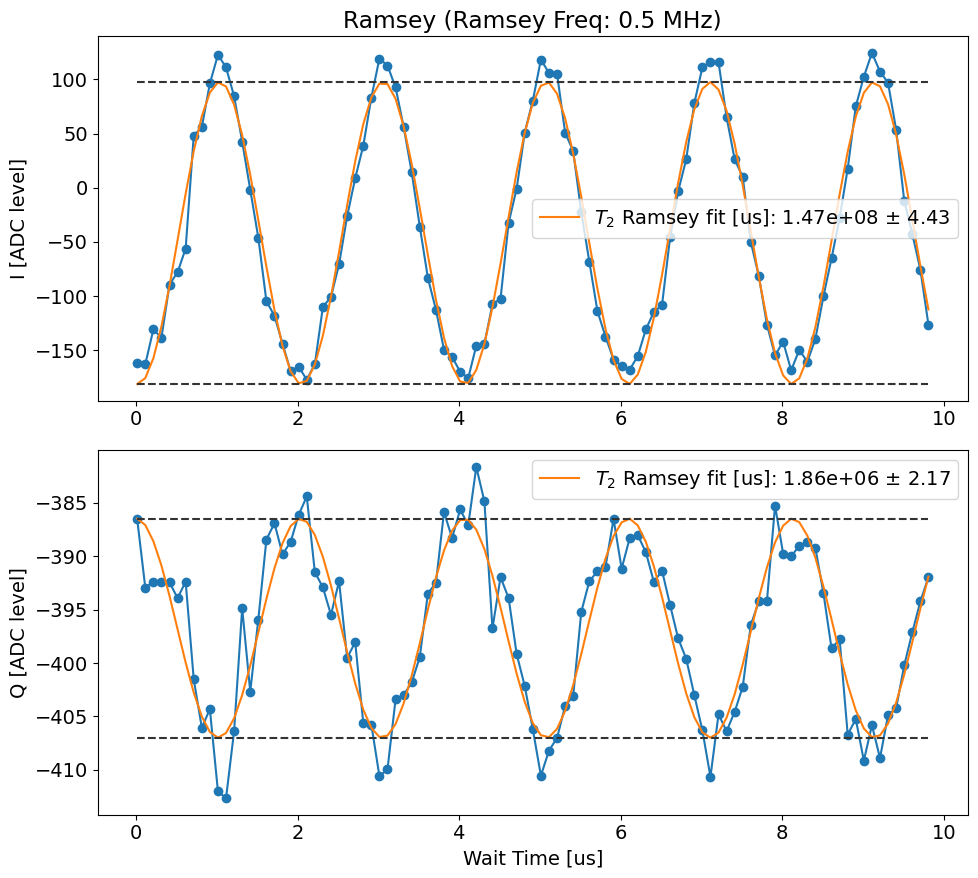

In [20]:
cavity_ramsey.display()

In [21]:
station.snapshot_hardware_config(update_main=True)

[CONFIG] Created new hardware_config version CFG-HW-20260403-00015
[CONFIG] Updated main hardware_config to CFG-HW-20260403-00015


'CFG-HW-20260403-00015'

## IMPORTANT: gain to alpha calibration

will do tomography on the vacuum state

$$
W_\alpha(\ket{0} \bra{0}) = \frac 2\pi e^{-2|\alpha|^2}
$$

In [8]:
do_parity_gain_defaults = AttrDict(dict(
    start=0,
    step=100,
    expts=40,
    reps=250,
    rounds=1,
    qubit=0,
    qubits=[0],
    normalize=False,
    single_shot=False,
    singleshot_reps=1000,
    singleshot_active_reset=False,
    singleshot_man_reset=True,
    singleshot_storage_reset=True,
    active_reset=False,
    man_reset=True,
    storage_reset=True,
    span=1000,
    prep_e=False,
    manipulate=1,
    displace=(True, 0.05), # [enable, sigma] (gaussian length is 4sigma)
    const_pulse=(False, 1), # [enable, length]
    f0g1_cavity=0,
    prepulse=False,
    pre_sweep_pulse=None,
    relax_delay=2500, 
    pulse_correction=False,
    parity_fast=False,
    scaling_amplitude=True,
    plot_IQ=True,
    man_mode_no=1,
))


def parity_gain_postproc(station, expt):
    expt_cfg = expt.cfg.expt
    scaling_amplitude = expt_cfg.scaling_amplitude
    man_mode_no = expt_cfg.man_mode_no
    if expt_cfg.plot_IQ:
        i_data = expt.data['idata']
        q_data = expt.data['qdata']
        fig, ax = plt.subplots(1,1, figsize=(6,6))
        ax.scatter(i_data, q_data, s=1, alpha=0.5)
        ax.set_xlabel('I')
        ax.set_ylabel('Q')
        ax.set_title('IQ Scatter Plot')
        plt.show()
    gain_to_alpha = expt.data['gain_to_alpha']
    old_gain_to_alpha = station.hardware_cfg.device.manipulate.gain_to_alpha[expt_cfg.man_mode_no - 1]
    print(f'Gain to alpha for mode {expt_cfg.man_mode_no} : {old_gain_to_alpha} -> {gain_to_alpha}')
    station.hardware_cfg.device.manipulate.gain_to_alpha[man_mode_no - 1] = gain_to_alpha
    if scaling_amplitude:
        scale = expt.data['scale']
        old_scale = station.hardware_cfg.device.manipulate.alpha_scale[man_mode_no - 1]
        station.hardware_cfg.device.manipulate.alpha_scale[man_mode_no - 1] = scale
        print(f'Scaling amplitude for mode {man_mode_no} : {old_scale} -> {scale}')




Job submitted: JOB-20260404-00063 (queue position: 1)

[0.1s] Job JOB-20260404-00063: pending

[2.1s] Job JOB-20260404-00063: running
[WORKER] Loading ParityGainExperiment from experiments.single_qubit.parity_gain
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260404-00063_ParityGainExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.1mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
4997.686201414042
Updating gain register 250
100%|███████████████████████████████████| 12000/12000 [00:30<00:00, 399.30it/s]
4997.686201414042
Updating gain register 250
 96%|█████████████████████████████████▍ | 11466/12000 [00:28<00:01, 399.16it/s]
[68.6s] Job JOB-20260404-00063: completed
100%|███████████████████████████████████| 12000/12000 [00:30<00:00, 399.35it/s]
plot: False
Gain to Alpha Conversion Factor: 0.00031141646728744996
alpha = 1 requires gain of : 3211.13397988
Saving D:\experiments\260403_qsim_calibrate_induce

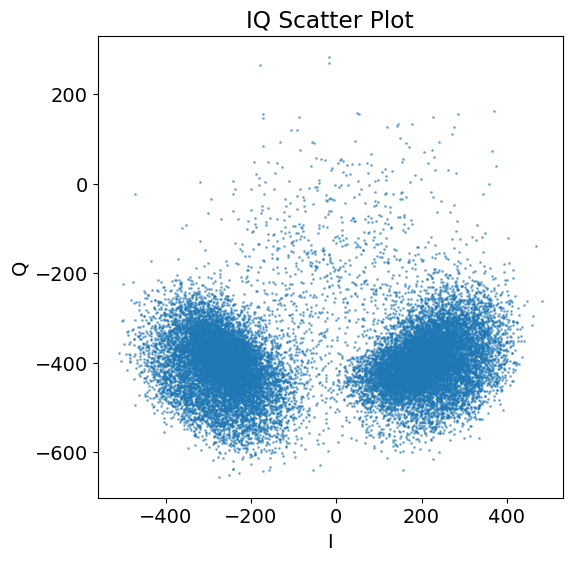

Gain to alpha for mode 1 : 0.0003118465928195334 -> 0.00031141646728744996
Scaling amplitude for mode 1 : 0.9815436218231269 -> 0.9713144084937809


In [9]:
parity_gain_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.single_qubit.parity_gain.ParityGainExperiment,
    default_expt_cfg=do_parity_gain_defaults,
    postprocessor=parity_gain_postproc,
    job_client=client,
    use_queue=USE_QUEUE,
)

parity_gain_expt = parity_gain_runner.execute(
    pulse_correction=True, # if number of photons in man is large, pi/2 pulses are bad. therefore, if pulse_correction = True: do a second set of parity measurements using pi/2, wait, -pi/2 and take the contrast between this measurement and the standard pi/2, wait, pi/2 parity measurement.
    reps=300,
    step=250,
    # priority=1,
    )


plot: True
Gain to Alpha Conversion Factor: 0.00031141646728744996


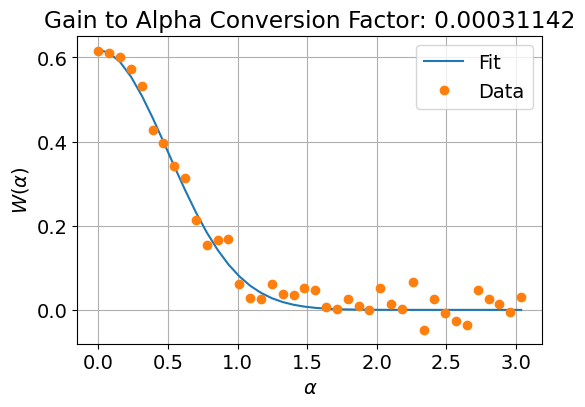

alpha = 1 requires gain of : 3211.13397988


{'idata': array([-220.44054054, -229.09459459, -209.44324324, ..., -191.76216216,
        -205.51081081, -322.90540541]),
 'qdata': array([-415.11621622, -397.99189189, -546.60540541, ..., -434.06216216,
        -422.82972973, -410.58648649]),
 'xpts': array([   0,  250,  500,  750, 1000, 1250, 1500, 1750, 2000, 2250, 2500,
        2750, 3000, 3250, 3500, 3750, 4000, 4250, 4500, 4750, 5000, 5250,
        5500, 5750, 6000, 6250, 6500, 6750, 7000, 7250, 7500, 7750, 8000,
        8250, 8500, 8750, 9000, 9250, 9500, 9750,    0,  250,  500,  750,
        1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500,
        3750, 4000, 4250, 4500, 4750, 5000, 5250, 5500, 5750, 6000, 6250,
        6500, 6750, 7000, 7250, 7500, 7750, 8000, 8250, 8500, 8750, 9000,
        9250, 9500, 9750]),
 'avgi': array([-244.06165766, -256.56844144, -247.34917117, -242.83689189,
        -205.35403604, -181.98259459, -178.21967568, -136.3239009 ,
        -144.3497027 , -101.32714414,  -90.30826126,  -76.

In [10]:
parity_gain_expt.analyze(scale=True, plot=True)

In [38]:
parity_gain_expt.data.keys()

dict_keys(['idata', 'qdata', 'xpts', 'avgi', 'avgq', 'amps', 'phases', 'gain_to_alpha', 'parity', 'scale'])

In [11]:
station.snapshot_hardware_config(update_main=True)

[CONFIG] Created new hardware_config version CFG-HW-20260403-00011
[CONFIG] Updated main hardware_config to CFG-HW-20260403-00011


'CFG-HW-20260403-00011'

# Qsim Wigner Tomography

## Generate Optimal Displacements 

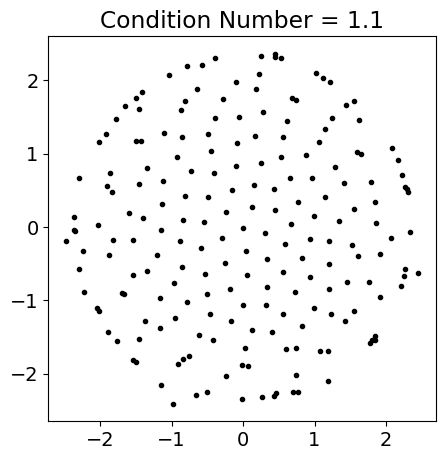

Displacements saved to D:\experiments\260227_qsim_purity_shots_test\optimized_displacements_1.npy


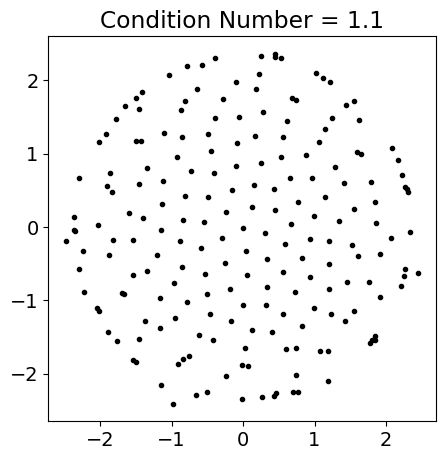

In [9]:
from fitting.wigner import OptimalDisplacementGeneration
# n_photon = 10 # maximum photon number to consider
n_photon = 8 # maximum photon number to consider
n_disps = 200 # number of displacements to use in the optimization
# n_photon = 15 # maximum photon number to consider
# n_disps = 300 # number of displacements to use in the optimization
opt_alphas = OptimalDisplacementGeneration(FD = n_photon, n_disps=n_disps)
return_dict = opt_alphas.optimize(save_dir = station.experiment_path)
return_dict_path = return_dict['path']

# Setup experiment

In [4]:
# station.ds_storage.update_pi('M1-S5', 0.0)
# station.ds_storage.update_h_pi('M1-S5', 0.0)
station.ds_storage.df

,stor_name,freq (MHz),precision (MHz),pi (mus),h_pi (mus),gain (DAC units),last_update,bs_rate_coeffs_g,bs_rate_coeffs_e,freq_coeffs_g,freq_coeffs_e,gain_range_g,gain_range_e,joint_parity,dr_ac_stark_rate,dr_jp_phase
0,M1-S1,352.804975,NaN,2.352172,1.176086,3145.0,2026-03-03 08:28:49.177729,"[-1.2836395105770435e-12, 1.562696017091276e-0...","[-1.0271277777566499e-12, 1.2180616293411382e-...","[2.416727059292405e-18, -4.5676836555436063e-1...","[1.0768268119126192e-17, -2.064263277889986e-1...","[3139.0413060452993, 4847.324955685794]","[3101.448831598782, 4790.574447085415]","[352.945277297742, 3613, 3.633305169492332, 3....",NaN,NaN
1,M1-S2,524.652154,NaN,2.066902,1.153536,4119.0,2026-03-03 08:31:21.402037,"[-1.4281651019406063e-14, 2.806388588329146e-1...","[-1.3801639995141456e-14, 2.522836838797176e-1...","[3.168997973536308e-13, -5.187532491475121e-09...","[1.5879651422642703e-13, -2.550878518704292e-0...","[3768.329130027269, 4601.31156086655]","[3734.908431473402, 4579.9722200091655]","[524.7952187148321, 4126, 3.5772383566017147, ...",NaN,NaN
2,M1-S3,700.803883,NaN,1.696505,0.848253,4754.0,2026-03-03 08:33:50.371545,"[5.6421716124194476e-14, -9.54652575391602e-10...","[5.3668931659321213e-14, -9.081097405814645e-1...","[6.6423838139356915e-15, -1.0891788247748665e-...","[7.707647124928997e-15, -1.287562445371084e-10...","[3691.6725579408326, 4750.653565000185]","[3675.6253949570655, 4747.5907746229]","[700.9623452312223, 3898, 3.5574971282155756, ...",NaN,NaN
3,M1-S4,880.746852,NaN,2.347447,1.173723,5724.0,2026-03-03 08:36:23.348135,"[1.3074330883632018e-13, -3.895577532599537e-0...","[1.0440734314418517e-13, -3.1165658095145888e-...","[-1.7911015967743975e-13, 5.255316029156036e-0...","[1.183456340477642e-13, -3.4848271304432547e-0...","[7130.408130290509, 7845.801085058587]","[7106.808810897533, 7826.805864093215]",NaN,NaN,NaN
4,M1-S5,1057.057548,NaN,2.833119,1.416560,6123.0,2026-02-21 15:08:17.529746,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,M1-S6,1248.744497,NaN,2.236056,0.902242,10382.0,2026-03-03 08:38:55.422709,"[-1.3966876001204708e-16, 6.9291826510581826e-...","[-2.6880391715732103e-16, 1.302538630495037e-1...","[3.8362619693507795e-16, -1.8777580937514096e-...","[4.2919235562169526e-16, -2.0702799090883976e-...","[10695.78483095193, 14045.482358218112]","[10727.35496738184, 14406.811373274053]","[1248.8666467863163, 11486, 3.482493636565513,...",NaN,NaN
6,M1-S7,1426.863489,NaN,2.983754,1.491877,9840.0,2026-03-03 08:41:26.225786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,M1-S8,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,M1-S9,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,M1-S10,-1.000000,-1.00,-1.000000,-1.000000,-1.0,51:31.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# station.ds_floquet.update_len('M1-S5', 0.0)
station.ds_floquet.df

,stor_name,pi_frac,freq (MHz),gain (DAC units),len (mus),ramp_sigma (mus),phase_from_M1-S1 (deg),phase_from_M1-S2 (deg),phase_from_M1-S3 (deg),phase_from_M1-S4 (deg),phase_from_M1-S5 (deg),phase_from_M1-S6 (deg),phase_from_M1-S7 (deg),last_update
0,M1-S1,15,352.805189,3062,0.155040,0.005008,0.000000,3.124849,-0.010766,0.0,0.0,0.000000,-12.480106,2026-02-23 18:45:42.755970
1,M1-S2,30,524.626255,3747,0.076902,0.005008,-3.492669,0.000000,-3.957270,0.0,0.0,-2.695980,-6.049181,2026-02-20 13:38:02.633819
2,M1-S3,40,700.807420,4717,0.042413,0.005008,0.524244,4.753306,0.000000,0.0,0.0,-0.697611,-2.604314,2026-02-20 13:38:02.639194
3,M1-S4,30,880.757057,7158,0.062183,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-20 13:38:02.643865
4,M1-S5,30,1056.917751,2493,0.000000,0.005008,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,2026-02-20 13:38:28.962114
5,M1-S6,40,1248.717666,12761,0.045112,0.005008,0.000000,3.591544,1.160044,0.0,0.0,0.000000,-0.994739,2026-02-20 13:38:02.652875
6,M1-S7,15,1426.859045,9317,0.177648,0.005008,17.044524,4.529378,1.914683,0.0,0.0,1.045383,0.000000,2026-02-23 18:46:36.593687


In [6]:
# return_dict_path = "D:\\experiments\\260218_qsim_scramble_low_kerr\\optimized_displacements_1.npy" # 200 displacements, cutoff=10
# return_dict_path = "D:\\experiments\\260218_qsim_scramble_low_kerr\\optimized_displacements_2.npy" # 250 displacements, cutoff=15
# return_dict_path = "D:\\experiments\\260227_qsim_purity_shots_test\\optimized_displacements.npy" # 300 displacements, cutoff=15
return_dict_path = "D:\\experiments\\260227_qsim_purity_shots_test\\optimized_displacements_1.npy" # 200 displacements, cutoff=8


qsim_wigner_defaults = AttrDict(dict(
    expts=1,
    reps=100,
    rounds=1,
    qubits=[0],
    ro_stor=0, # storage mode number that gets read out in the end

    init_fock=False,
    displacement_path=return_dict_path, # optimal displacement path
    perform_wigner=True,
    parity_fast=False,
    pulse_correction=True,

    # wait_us_times=np.linspace(0, 5, 10).tolist(),
    # swept_params = ['wait_us_time'],

    # Use SweepRunner to handle the sweeping
    # dummys=[0],
    # swept_params=['dummy'],

    normalize=False,
    post_select_pre_pulse=False,
    active_reset=False,
    man_reset=False, 
    storage_reset=False, 
    prepulse=True,
    postpulse=True,
)) # Shouldn't be modifying this on the fly!
# You can use kwargs in the run function to override these values

def qsim_wigner_preproc(station, default_expt_cfg, **kwargs):
    assert 'swept_params' in kwargs
    assert len(kwargs['swept_params']) > 0

    expt_cfg = deepcopy(default_expt_cfg)
    expt_cfg.update(kwargs)
    assert 'init_stor' in kwargs
    if not expt_cfg.init_fock:
        assert 'init_alpha' in kwargs

    print(expt_cfg)
    return expt_cfg

## Kerr wait

In [ ]:
fnames_kerr_wait = []

In [ ]:
wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    ExptProgram=meas.KerrWaitProgram,
    default_expt_cfg=qsim_wigner_defaults,
    preprocessor=qsim_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

wait_times = np.linspace(0, 100, 26)
# wait_times = [0]
print("wait_times (us)", wait_times)

for i, wait_time in enumerate(wait_times):
    # if i < 5: continue

    print("wait_time", wait_time)
    wigner = wigner_runner.execute(
        reps=200,

        # init_fock=False,
        # init_alpha=1.0,

        init_fock=False,
        init_alpha=False,
        init_man_fock_state='+',

        init_stor=0,
        ro_stor=0,
        # relax_delay=2500,

        wait_us_times=[wait_time],
        swept_params=['wait_us_time'],

        active_reset=True,
        man_reset=True,
        storage_reset=False,
        use_qubit_man_reset=True,
        pre_selection_reset=False,
        relax_delay=1500,
        # priority=1,
    )
    fnames_kerr_wait.append(wigner.fname)

## Scramble

In [17]:
# floquet_cycles = np.arange(1, 100, step=5)
# floquet_cycles = [0, 2, 3]
floquet_cycles = [0]
print(floquet_cycles)

[0]


In [18]:
fnames = []

Starting floquet_cycle 0 ro_stor 0
rerunning single shot
Job submitted: JOB-20260304-00020 (queue position: 1)

[0.1s] Job JOB-20260304-00020: pending

[2.1s] Job JOB-20260304-00020: running
[WORKER] Loading HistogramExperiment from experiments.single_qubit.single_shot
[WORKER] Creating experiment instance
[WORKER]   Data file: JOB-20260304-00020_HistogramExperiment.h5
[WORKER] Running experiment...
[WORKER] Setting coupler yoko current to 0.5mA according to hardware_cfg yaml...
[WORKER] Done setting coupler current
 66%|████████████████████████▏            | 3276/5000 [00:06<00:03, 498.87it/s]
[26.5s] Job JOB-20260304-00020: completed
100%|█████████████████████████████████████| 5000/5000 [00:10<00:00, 499.34it/s]
Unrotated:
Ig -300.50540540540544 +/- 84.95279846140724 	 Qg -406.3797297297297 +/- 71.72551157169707 	 Amp g 505.4186219492464
Ie 168.97027027027028 +/- 115.88144453795965 	 Qe -422.52027027027026 +/- 68.19499537464914 	 Amp e 455.05420668802793
Rotated:
Ig -286.123397133156

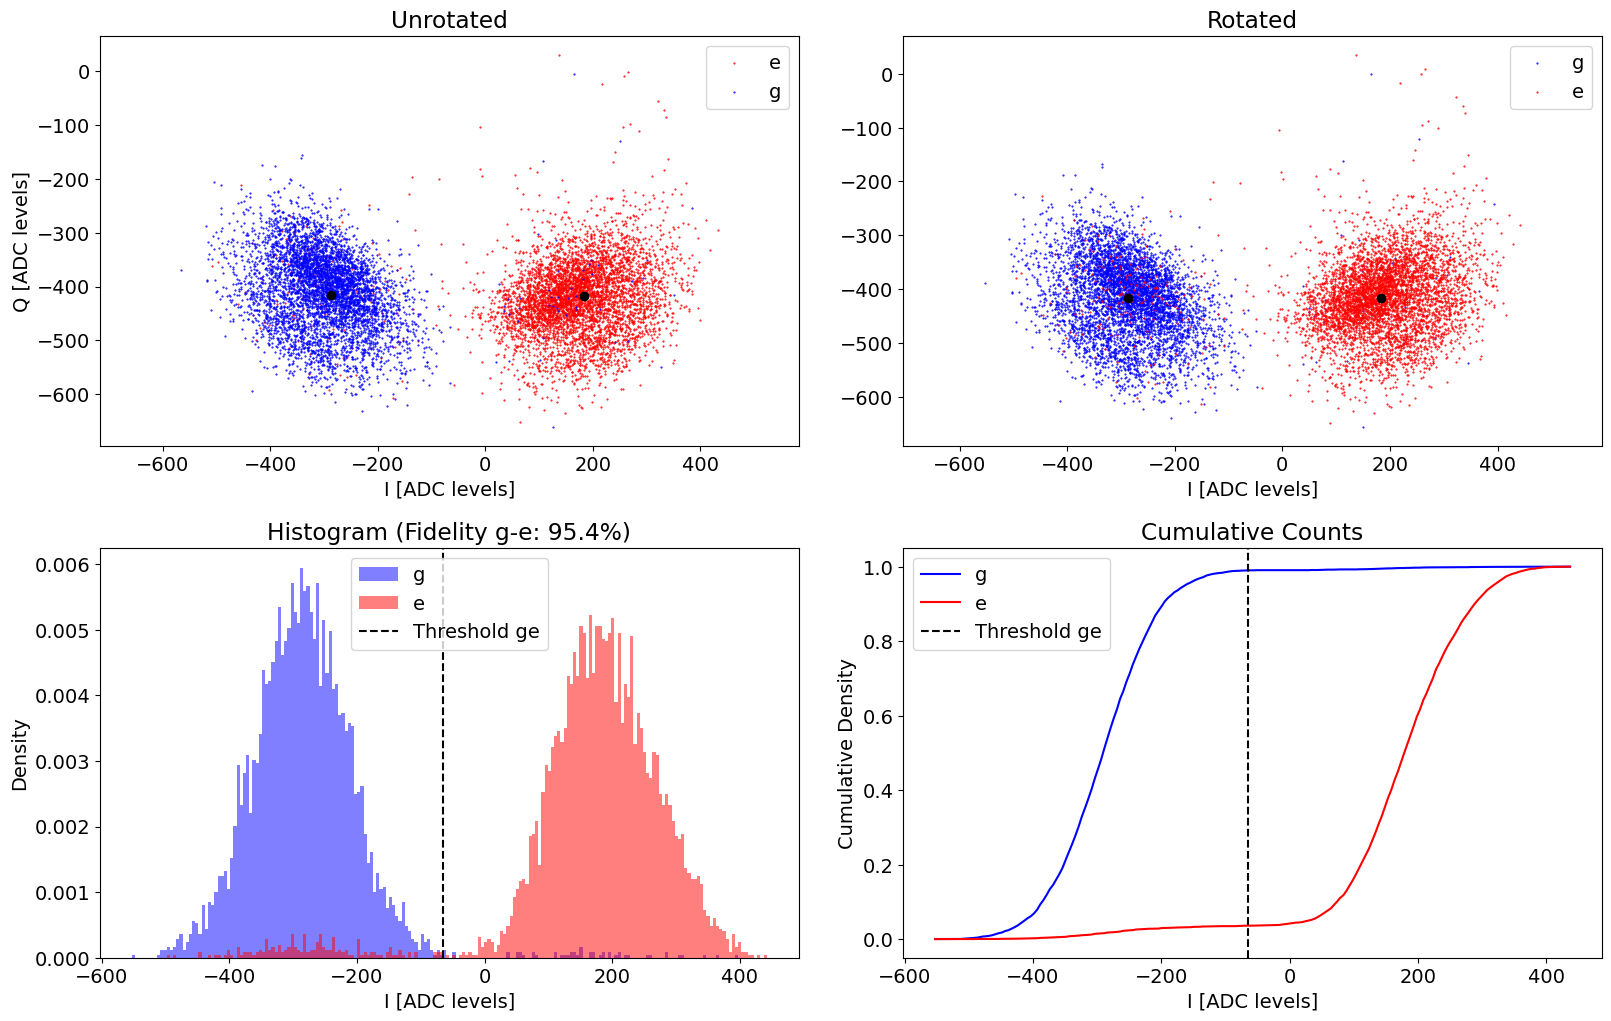

Plot saved to D:\experiments\260227_qsim_purity_shots_test\plots\2026-03-04_14-26-01_histogram.png
Plot reference appended to D:\experiments\260227_qsim_purity_shots_test\logs\2026-03-04.md
ge fidelity (%): 95.41999999999999
rotation angle (deg): 1.969049301561521
threshold ge: -65.38731507696087
{'expts': 1, 'reps': 1000, 'rounds': 1, 'qubits': [0], 'ro_stor': 0, 'init_fock': False, 'displacement_path': 'D:\\experiments\\260227_qsim_purity_shots_test\\optimized_displacements_1.npy', 'perform_wigner': True, 'parity_fast': False, 'pulse_correction': True, 'normalize': False, 'post_select_pre_pulse': False, 'active_reset': True, 'man_reset': True, 'storage_reset': [1, 7], 'prepulse': True, 'postpulse': True, 'init_alpha': 1.0, 'init_stor': 0, 'swap_stors': [1, 7], 'update_phases': True, 'floquet_cycles': [0], 'swept_params': ['floquet_cycle'], 'use_qubit_man_reset': True, 'pre_selection_reset': False, 'relax_delay': 1500}
Job submitted: JOB-20260304-00021 (queue position: 1)

[0.1s] Job 

In [20]:
wigner_runner = CharacterizationRunner(
    station=station,
    ExptClass=meas.QsimWignerBaseExperiment,
    # ExptProgram=meas.KerrWaitProgram,
    ExptProgram=meas.SidebandScrambleProgram,
    default_expt_cfg=qsim_wigner_defaults,
    preprocessor=qsim_wigner_preproc,
    postprocessor=None,
    job_client=client,
)

swap_stors = [1, 7]
# ro_stors = [0, *swap_stors]
ro_stors = [0, 0, 0]

for ro_stor in ro_stors:
    fnames.append([])

for i, floquet_cycle in enumerate(floquet_cycles):
    # if i < 13: continue

    for i_ro_stor, ro_stor in enumerate(ro_stors):

        print("Starting", "floquet_cycle", floquet_cycle, "ro_stor", ro_stor)

        if i % 3 == 0 and i_ro_stor == 0:
            print("rerunning single shot")
            ss_runner = CharacterizationRunner(
                station = station,
                ExptClass = meas.HistogramExperiment,
                default_expt_cfg = singleshot_defaults,
                postprocessor = singleshot_postproc,
                job_client=client,
            )

            ss = ss_runner.execute(
                check_f=False,
                relax_delay=2000,
                priority=1,
            )
            ss.display(station)
            plt.show()

        wigner = wigner_runner.execute(
            reps=1000,
            # reps=200,
            # reps=10,
            init_fock=False,
            init_alpha=1.0,
            init_stor=0,
            ro_stor=ro_stor,

            # wait_us_times=np.linspace(0, 10, 11).tolist(),
            # swept_params=['wait_us_time'],

            swap_stors=swap_stors,
            update_phases=True,
            floquet_cycles=[floquet_cycle],
            swept_params=['floquet_cycle'],


            # active_reset=False,
            # relax_delay=2500,

            active_reset=True,
            man_reset=True,
            storage_reset=swap_stors,
            use_qubit_man_reset=True,
            pre_selection_reset=False,
            relax_delay=1500,
        )

        fnames[i_ro_stor].append(wigner.fname)

        print("fnames so far", fnames)

In [21]:
fnames

[['D:\\experiments\\260227_qsim_purity_shots_test\\data\\JOB-20260304-00017_QsimWignerBaseExperiment.h5',
  'D:\\experiments\\260227_qsim_purity_shots_test\\data\\JOB-20260304-00021_QsimWignerBaseExperiment.h5'],
 ['D:\\experiments\\260227_qsim_purity_shots_test\\data\\JOB-20260304-00018_QsimWignerBaseExperiment.h5',
  'D:\\experiments\\260227_qsim_purity_shots_test\\data\\JOB-20260304-00022_QsimWignerBaseExperiment.h5'],
 ['D:\\experiments\\260227_qsim_purity_shots_test\\data\\JOB-20260304-00019_QsimWignerBaseExperiment.h5',
  'D:\\experiments\\260227_qsim_purity_shots_test\\data\\JOB-20260304-00023_QsimWignerBaseExperiment.h5'],
 [],
 [],
 []]

## Analyze

27 None
shape (201, 200)
max parity: 0.9847479931112219
max parity before scaling: 0.9501689189189187
Analyzing for floquet_cycle=27, dummy=None


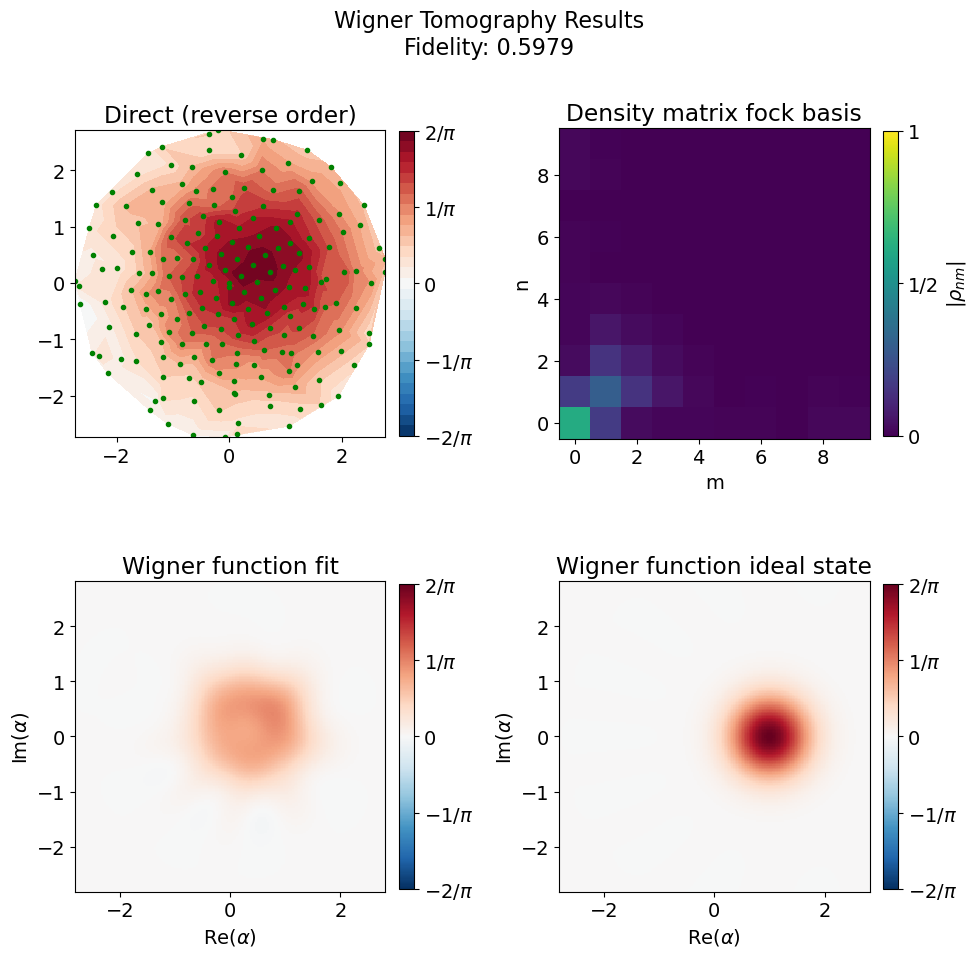

In [ ]:
cutoff = 10
# ideal_state = (qt.basis(cutoff, 0)+qt.basis(cutoff, 4)).unit()
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
wigner.analyze_wigner(mode_state_num=cutoff, debug=True)
wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)

## Reopen old data

1 None
shape (201, 50)
max parity: 1.0907067808297253
max parity before scaling: 0.9188034188034189
Analyzing for floquet_cycle=1, dummy=None
6 None
shape (201, 50)
max parity: 1.0399762328841566
max parity before scaling: 0.8760683760683762
Analyzing for floquet_cycle=6, dummy=None
11 None
shape (201, 50)
max parity: 1.065341506856941
max parity before scaling: 0.8974358974358975
Analyzing for floquet_cycle=11, dummy=None
16 None
shape (201, 50)
max parity: 1.065341506856941
max parity before scaling: 0.8974358974358975
Analyzing for floquet_cycle=16, dummy=None
21 None
shape (201, 50)
max parity: 1.0399762328841566
max parity before scaling: 0.8760683760683762
Analyzing for floquet_cycle=21, dummy=None
26 None
shape (201, 50)
max parity: 1.0399762328841564
max parity before scaling: 0.876068376068376
Analyzing for floquet_cycle=26, dummy=None


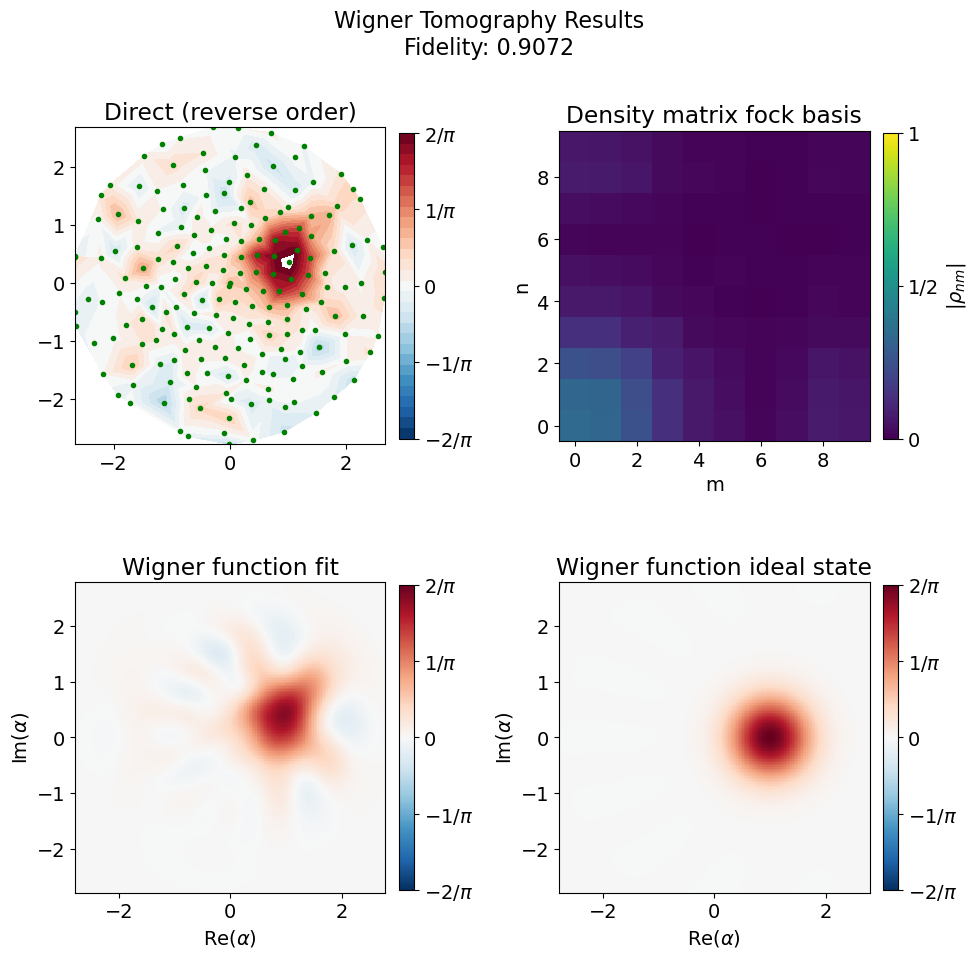

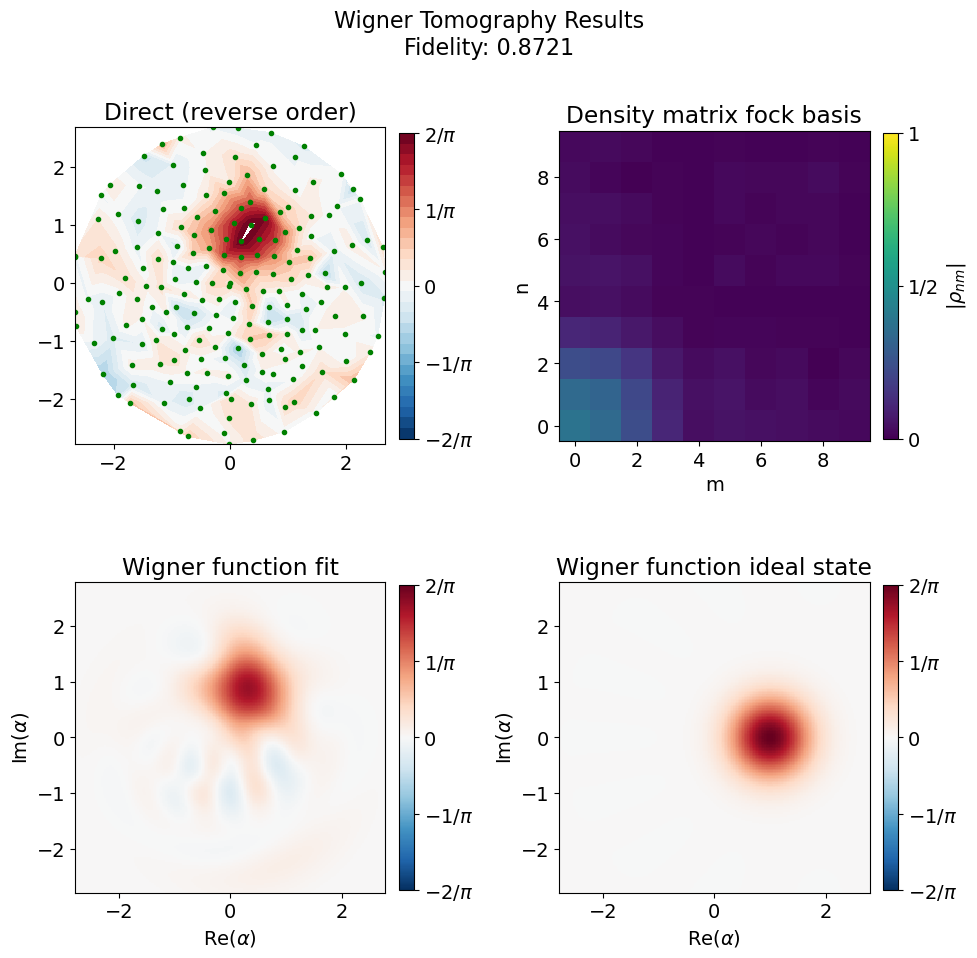

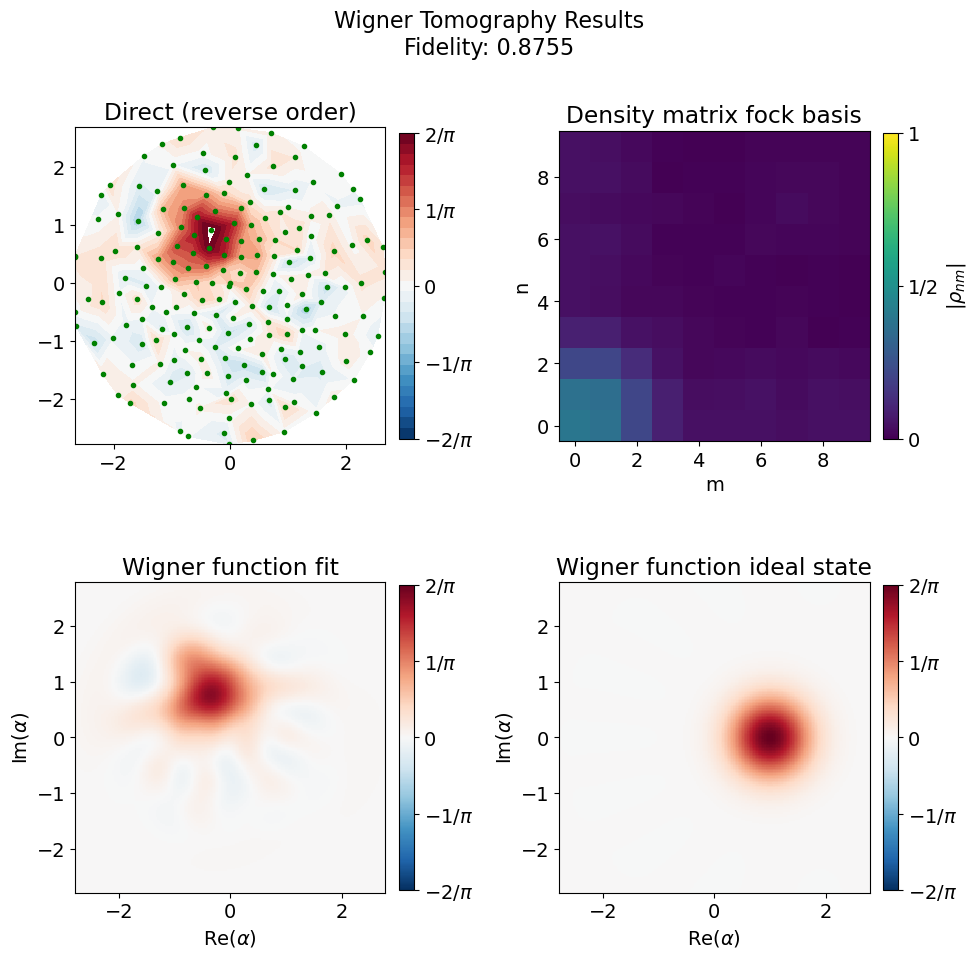

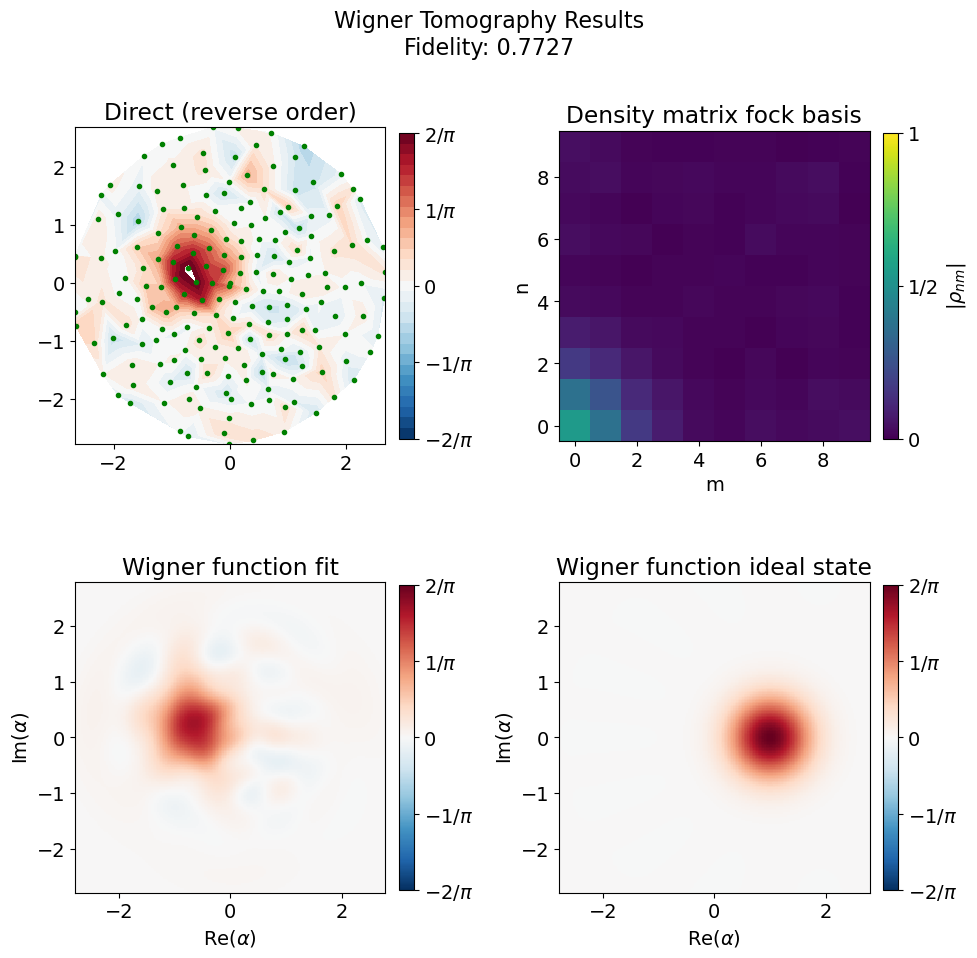

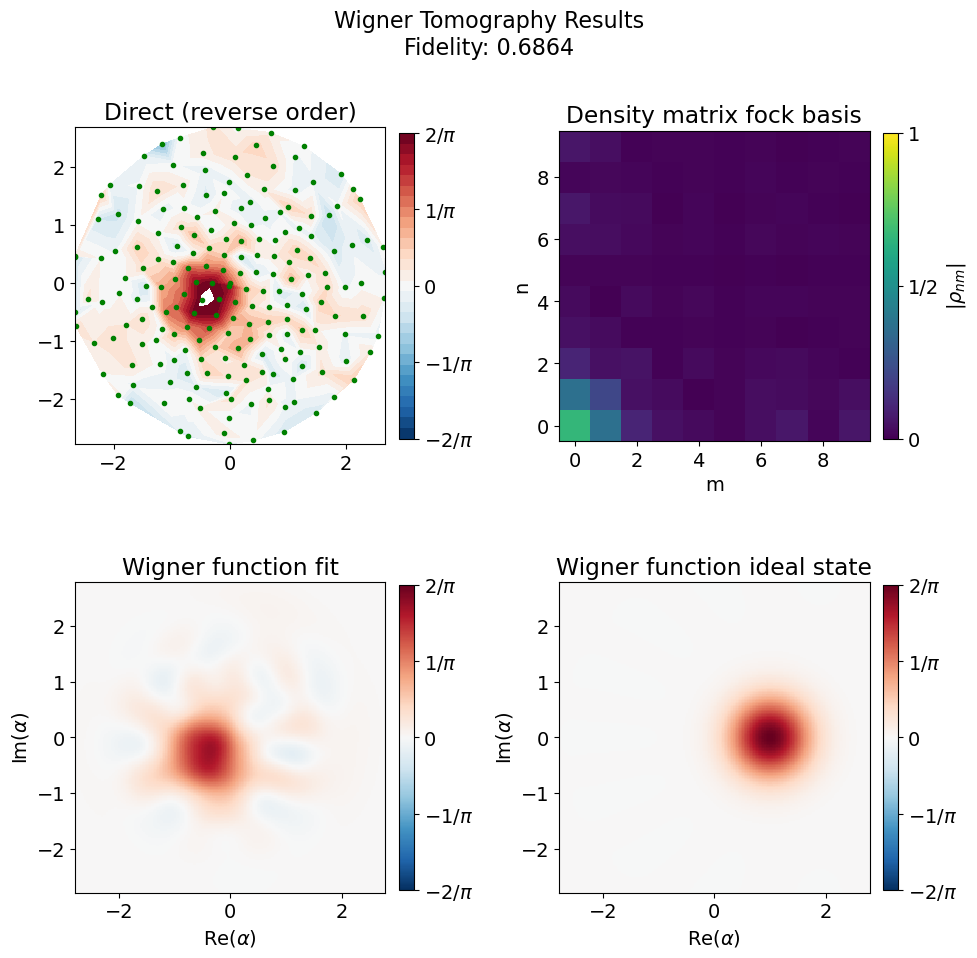

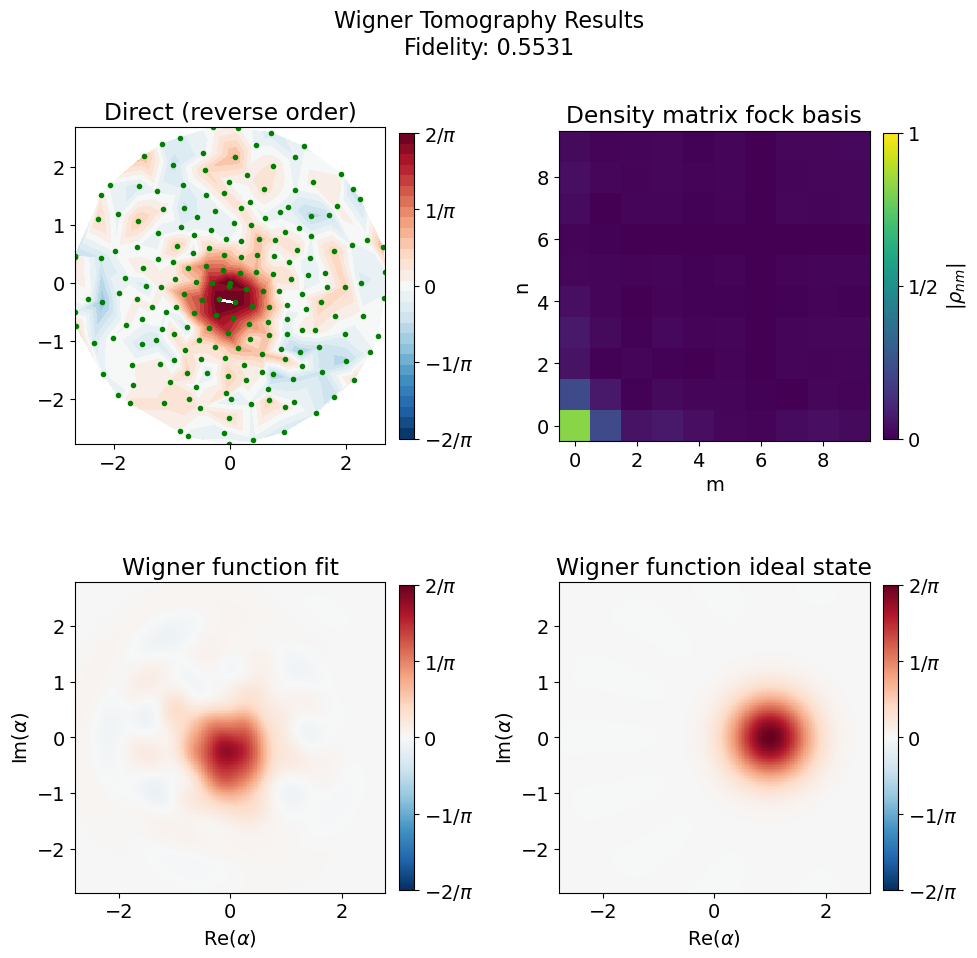

In [ ]:
# Reopen old data
import pickle

pkl_files = [
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00129_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00131_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00133_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00134_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00136_expt.pkl",
"D:\\experiments\\260128_qsim_wigner\\expt_objs\\JOB-20260204-00138_expt.pkl"
]

cutoff = 10
ideal_state = (qt.coherent(cutoff, 1.0)).unit()
floquet_cycles = np.arange(1, 50, step=5)

for i, pkl_file in enumerate(pkl_files):
    with open(pkl_file, "rb") as f:
        test_wigner = pickle.load(f)
        test_wigner.analyze_wigner(cutoff=cutoff, debug=True)
        test_wigner.display(rotate=True, initial_state=ideal_state, mode_state_num=cutoff, station=station, save_fig=False)
        plt.show()

In [ ]:
# test_wigner = meas.QsimWignerBaseExperiment(config_file=station.hardware_config_file, expt_params=kerr_wait_wigner_defaults)
# test_wigner.data = wigner.data
# test_wigner.outer_params = wigner.outer_params
# test_wigner.inner_params = wigner.inner_params
# test_wigner.outer_param = wigner.outer_param
# test_wigner.inner_param = wigner.inner_param
# test_wigner.pulse_correction = wigner.pulse_correction
# test_wigner.cfg = deepcopy(wigner.cfg)

# test_wigner.analyze_wigner(mode_state_num=10)